Create Model 1 using Tensorflow

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import PIL

from tensorflow import keras
from tensorflow.keras import layers

datasetPath = kagglehub.dataset_download("ongshujian/real-and-fake-pokemon-cards")

def build_tensor_deep_model(hp):
    base_filters = hp.Choice("base_filter", [16, 32]) # for feature extraction
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"]) # activation function.
    model = keras.models.Sequential([
        layers.Conv2D(base_filters, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 2, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 4, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model



Using Colab cache for faster access to the 'real-and-fake-pokemon-cards' dataset.


Process the data and split into training and validation sets. Use Tensorflows function to work.

Trial 16 Complete [00h 00m 12s]
val_accuracy: 0.6666666865348816

Best val_accuracy So Far: 0.8399999737739563
Total elapsed time: 00h 02m 49s
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 385ms/step - accuracy: 0.5839 - loss: 1.7538 - val_accuracy: 0.6667 - val_loss: 0.6560
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6879 - loss: 0.5897 - val_accuracy: 0.8133 - val_loss: 0.5055
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7685 - loss: 0.4843 - val_accuracy: 0.7200 - val_loss: 0.5869
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7718 - loss: 0.4707 - val_accuracy: 0.8133 - val_loss: 0.4342
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7886 - loss: 0.4814 - val_accuracy: 0.8400 - val_loss: 0.4028
Index(['base_filter', 'dense_units', 'activation', 'score'], dtype='object')
   base_filter  dense_units activation     score
0           16           64       relu  0.800000
1           16           64    sigmoid  0.333333
2 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,816,072 (148.07 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,877,382 (98.71 MB)

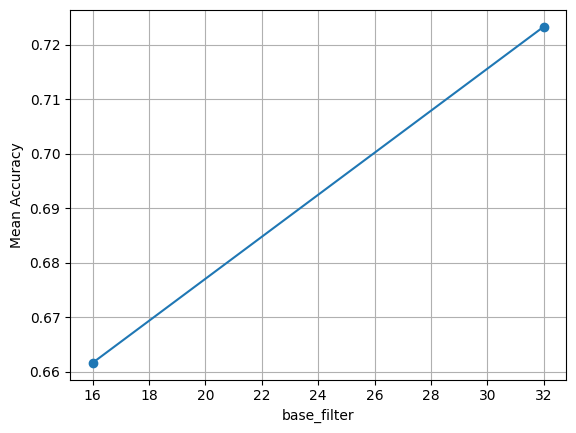

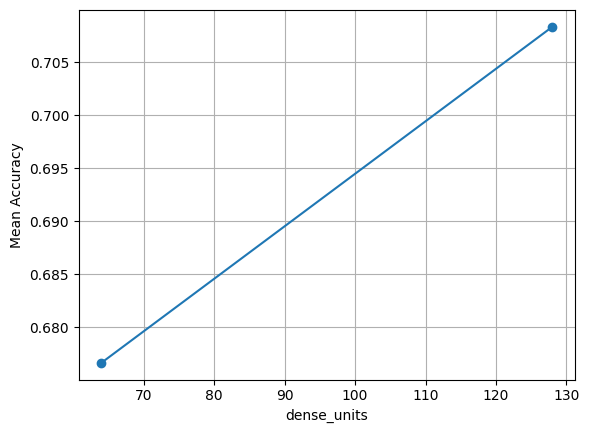

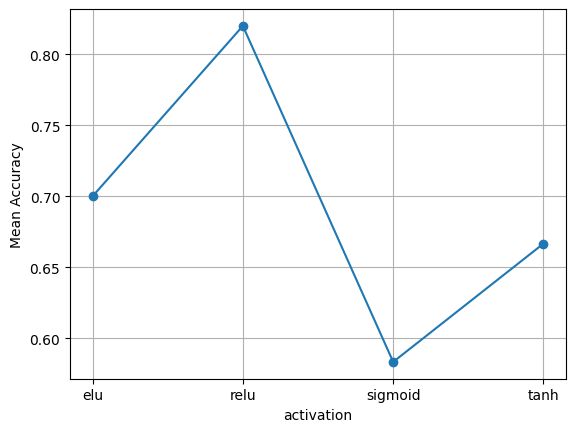

In [ ]:
#install keras tuner so we can tune hypermodels in Tensorflow
%pip install -q -U keras-tuner

import os
#we'll use this tool for training validation split for relative ease of use
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import keras_tuner as kt

df = pd.read_csv(f"{datasetPath}/train_labels.csv") 
#shuffle dataset because the original dataset is ordered. We want to keep 
photoID_training, photoID_valid, classify_training, classify_valid = train_test_split(
    df["id"], df["label"],
    test_size= .2,
    stratify = df["label"],
    random_state=42
)


def processThroughImages(imagesCollection, labels, stage):
    imagesArray = []
    labelToReturn= []
    # Images 1 - 298 in our dataset will be our training data. Rest will be testing
    for imageID, label in zip(imagesCollection, labels):
        imageToProcessFilePath = os.path.join(datasetPath, stage, f"{imageID}.JPG")
        
        if not os.path.exists(imageToProcessFilePath):
            print(f"Missing: {imageToProcessFilePath}")
            continue

        imageToProcess = keras.utils.img_to_array(keras.utils.load_img(imageToProcessFilePath, target_size=[224,224]))
        
        imagesArray.append(imageToProcess)
        labelToReturn.append(label)
    
    
    return np.array(imagesArray), np.array(labelToReturn)

trainingImagesArray, trainingClassifyArray = processThroughImages(photoID_training, classify_training, "train")
validationImagesArray, validationClassifyArray = processThroughImages(photoID_valid, classify_valid, "train")

#normalize for model's ease
trainingImagesArray /= 255.0
validationImagesArray /= 255.0

# hypertune parameters with model 1 and see what we can do
model1Tuner = kt.GridSearch(
    build_tensor_deep_model,
    objective="val_accuracy",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierDeepModel"
)

model1Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

# display our results of our tuning here. 
def showHyperPlot(param: str, results, groupBy="mean_test_score"):
  toPlot = results.groupby(param)[groupBy].mean()
  plt.figure()
  plt.plot(toPlot.index, toPlot.values, marker="o")
  plt.xlabel(param)
  plt.ylabel("Mean Accuracy")
  plt.grid(True)
  plt.show()




# rebuild with best hyperparameters and get our final tuned model
model1 = model1Tuner.hypermodel.build(model1Tuner.get_best_hyperparameters(1)[0])

model1.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model1Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model1Tuner.oracle.trials.values() if t.score is not None
])
print(model1Results.columns)
print(model1Results.head())


model1.summary()
showHyperPlot("base_filter", model1Results, "score")
showHyperPlot("dense_units", model1Results, "score")
showHyperPlot("activation", model1Results, "score")

Let's try creation a second model and see which one is more accurate. We're going to build a Tensorflow shallow learning model (even if it is not recommended for image processing and classification) and see if it could ever beat it.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#Let's tune hyperparameters
def build_tensor_shallow_model(hp):
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions1 = hp.Choice("activation1", ["relu", "sigmoid", "tanh", "elu"])
    activeFunctions2 = hp.Choice("activation2", ["relu", "sigmoid", "tanh", "elu"]) # activation function.
    model = keras.models.Sequential([
        layers.Input(shape=(10, )),
        layers.Dense(dense_units, activation=activeFunctions1),
        layers.Dense(1, activation=activeFunctions2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model

model2Tuner = kt.GridSearch(
    build_tensor_shallow_model,
    objective="val_accuracy",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierShallowModel"
)

model2Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model2Tuner.oracle.trials.values() if t.score is not None
])

model2 = model2Tuner.hypermodel.build(model2Tuner.get_best_hyperparameters(1)[0])

model2.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2.summary()
showHyperPlot("dense_units", model2Results, "score")
showHyperPlot("activation1", model2Results, "score")
showHyperPlot("activation2", model2Results, "score")

Reloading Tuner from fakeCardTensorflowLogs/pokemonFakeCardClassifier/tuner0.json
Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 224, 224, 3), dtype=float32) with name 'keras_tensor_30' and path ''. Expected shape (None, 10), but input has incompatible shape (None, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Test it on the test data we have set, then compare the two models. Pick the best one from here and export as a backend api

In [6]:
#prepare test set
testDF = pd.read_csv(f"{datasetPath}/test_labels.csv").sample(frac=1, random_state=42).reset_index(drop=True)
testImagesArray, testClassifyArray = processThroughImages(testDF["id"], testDF["label"], "test")
# test model 1
testCheck1 = np.argmax(model1.predict(testImagesArray), axis=1)
print(f"Model 1 accuracy: {accuracy_score(testClassifyArray, testCheck1)}")
print(classification_report(testClassifyArray, testCheck1, target_names=["Fake Cards", "Real Cards"]))
# test model 2
testCheck2 = model2.predict(flattenArrays(testImagesArray))
print(f"Model 2 accuracy: {accuracy_score(testClassifyArray, testCheck2)}")
print(classification_report(testClassifyArray, testCheck2, target_names=["Fake Cards", "Real Cards"]))





3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step
Model 1 accuracy: 0.9102564102564102
              precision    recall  f1-score   support

  Fake Cards       0.96      0.79      0.86        28
  Real Cards       0.89      0.98      0.93        50

    accuracy                           0.91        78
   macro avg       0.92      0.88      0.90        78
weighted avg       0.91      0.91      0.91        78

Model 2 accuracy: 0.358974358974359
              precision    recall  f1-score   support

  Fake Cards       0.36      1.00      0.53        28
  Real Cards       0.00      0.00      0.00        50

    accuracy                           0.36        78
   macro avg       0.18      0.50      0.26        78
weighted avg       0.13      0.36      0.19        78



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
